# Регрессия SI. Предсказание индекса селективности SI = CC50/IC50 против вируса гриппа

### Выполнил: А.Любошенко

**Цель:** построить и сравнить регрессионные модели для предсказания `log1p(SI)`. Лучшая модель позволит предсказывать индекса селективности SI = CC50/IC50 по структурным дескрипторам нового соединения.

**Биологический смысл:** больше SI -> лучше баланс эффективности и безопасности

> **Важно:** SI = CC50/IC50. При предсказании SI **не используем IC50 и CC50 как признаки** -- это data leakage. Только молекулярные дескрипторы.

**Этапы работы:**
1. Загрузка данных и препроцессинг (план из EDA)
2. Ridge Regression -- L2-регуляризованный baseline
3. Lasso Regression -- L1 + неявный отбор признаков
4. Random Forest Regressor -- ансамблевый метод
5. LightGBM Regressor -- градиентный бустинг
6. SVR -- Support Vector Regression
7. Сравнение моделей
8. Важность признаков и анализ остатков
9. Выводы

**Метрики:** R^2 (в log-пространстве), RMSE и MAE -- в исходном масштабе через `expm1`


In [1]:
# Все импорты в одну ячейку

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import time
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print("Импорты выполнены успешно.")


Импорты выполнены успешно.


## 1. Загрузка данных и препроцессинг

Применяю план из EDA:
1. Удалить 18 zero-variance признаков
2. Медианная импутация 12 колонок с пропусками
3. `log1p(SI)` -- нормализует правоскошенное распределение (skew SI: 3.67 -> -0.03 для IC50, 1.97 -> -0.91 для CC50, 18.01 -> 1.43 для SI)
4. Разбивка train/test = 80/20, random_state=42
5. StandardScaler -- для Ridge, Lasso, SVR


In [2]:
ZERO_VAR_COLS = [
    'NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH',
    'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo',
    'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam',
    'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan'
]  # 18 zero-variance признаков, выявленных в EDA

IMPUTE_COLS = [
    'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge',
    'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO',
    'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW'
]  # 12 колонок с пропусками (по 3 NaN каждая)

ALL_TARGETS = ['IC50', 'CC50', 'SI']

TARGET = 'SI'

df = pd.read_csv('data_of_course_paper.csv')
print(f"Загружено: {df.shape}")

# Удаляем zero-variance признаки (выявлены в EDA -- несут нулевую информацию)
df = df.drop(columns=ZERO_VAR_COLS)
print(f"После удаления zero-variance: {df.shape}")

# Медианная импутация -- устойчива к скошенным распределениям
for col in IMPUTE_COLS:
    df[col] = df[col].fillna(df[col].median())
print(f"Пропуски после импутации: {df.isnull().sum().sum()}")


Загружено: (1001, 213)
После удаления zero-variance: (1001, 195)
Пропуски после импутации: 0


In [3]:
feature_cols = [c for c in df.columns if c not in ALL_TARGETS]

X = df[feature_cols].values
y = np.log1p(df[TARGET].values)  # log1p-преобразование: обосновано в EDA

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler fit только на train -- нет утечки тестовых данных
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Признаков: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]} объектов | Test: {X_test.shape[0]} объектов")
print(f"log1p({TARGET}): train mean={y_train.mean():.3f}, std={y_train.std():.3f}")


Признаков: 192
Train: 800 объектов | Test: 201 объектов
log1p(SI): train mean=2.050, std=1.429


#### Препроцессинг завершён

- 192 признака (было 210, удалено 18 zero-variance)
- Пропуски устранены медианной импутацией
- Целевая переменная: `log1p(SI)` -- нормализует распределение
- Train 801 / Test 200 объектов


## 2. Ridge Regression (baseline)

**Ridge** -- линейная регрессия с L2-регуляризацией. Сжимает коэффициенты к нулю без обнуления.
При 192 признаках и 801 объекте регуляризация обязательна. Параметр `alpha` подбираем GridSearchCV.


In [4]:
t0 = time.time()

param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}

cv_ridge = GridSearchCV(
    Ridge(max_iter=5000),
    param_grid_ridge,
    cv=3, scoring='r2', n_jobs=-1, verbose=0
)
cv_ridge.fit(X_train_sc, y_train)
elapsed = time.time() - t0

print(f"GridSearchCV: {elapsed:.1f} с | лучший alpha={cv_ridge.best_params_['alpha']}")
print(f"CV R^2 (5-fold): {cv_ridge.best_score_:.4f}")

best_ridge = cv_ridge.best_estimator_
y_pred_log = best_ridge.predict(X_test_sc)

ridge_cv_r2 = cv_ridge.best_score_
ridge_r2    = r2_score(y_test, y_pred_log)
ridge_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log)))
ridge_mae   = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log))

print(f"Test R^2:   {ridge_r2:.4f}")
print(f"Test RMSE: {ridge_rmse:.2f}")
print(f"Test MAE:  {ridge_mae:.2f}")


GridSearchCV: 2.4 с | лучший alpha=100.0
CV R^2 (5-fold): 0.1607
Test R^2:   0.1850
Test RMSE: 1424.98
Test MAE:  179.92


#### Ridge: результаты baseline получены

Ожидаем умеренный R^2 -- в QSAR-задачах линейных зависимостей, как правило, недостаточно (max |корр.| признаков с таргетом < 0.28 по данным EDA).


## 3. Lasso Regression (L1 + отбор признаков)

**Lasso** с L1-регуляризацией обнуляет коэффициенты нерелевантных признаков -- производит **неявный отбор признаков**. Это помогает понять, какое минимальное подмножество дескрипторов линейно объясняет `SI`.


In [5]:
t0 = time.time()

param_grid_lasso = {'alpha': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}

cv_lasso = GridSearchCV(
    Lasso(max_iter=20000),
    param_grid_lasso,
    cv=3, scoring='r2', n_jobs=-1, verbose=0
)
cv_lasso.fit(X_train_sc, y_train)
elapsed = time.time() - t0

print(f"GridSearchCV: {elapsed:.1f} с | лучший alpha={cv_lasso.best_params_['alpha']}")
print(f"CV R^2 (5-fold): {cv_lasso.best_score_:.4f}")

best_lasso = cv_lasso.best_estimator_
y_pred_log = best_lasso.predict(X_test_sc)

lasso_cv_r2 = cv_lasso.best_score_
lasso_r2    = r2_score(y_test, y_pred_log)
lasso_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log)))
lasso_mae   = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log))

n_nonzero = (best_lasso.coef_ != 0).sum()
print(f"Признаков с ненулевым коэффициентом: {n_nonzero} из {X_train.shape[1]}")
print(f"Test R^2:   {lasso_r2:.4f}")
print(f"Test RMSE: {lasso_rmse:.2f}")
print(f"Test MAE:  {lasso_mae:.2f}")


GridSearchCV: 4.1 с | лучший alpha=0.05
CV R^2 (5-fold): 0.1253
Признаков с ненулевым коэффициентом: 40 из 192
Test R^2:   0.1638
Test RMSE: 1426.70
Test MAE:  180.28


#### Lasso: число отобранных признаков -- ключевое наблюдение

Если Lasso отбирает < 30 признаков при схожем R^2 с Ridge -- задача имеет компактное линейное описание. Если отбирает 100+ -- мультиколлинеарность мешает L1, и Ridge предпочтительнее.


## 4. Random Forest Regressor (ансамблевый метод)

**Random Forest** -- ансамбль деревьев на бутстрэп-выборках. Преимущества для нашей задачи:
- Устойчив к выбросам (SI имеет 89 выбросов при 3xIQR)
- Хорошо работает со смешанными типами (104 float + 88 int признаков)
- Не требует масштабирования
- Даёт MDI-важность признаков

Пространство гиперпараметров большое -> `RandomizedSearchCV` (n_iter=25).


In [6]:
t0 = time.time()

param_dist_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

cv_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist_rf,
    n_iter=8, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
cv_rf.fit(X_train, y_train)  # RF не требует масштабирования
elapsed = time.time() - t0

print(f"RandomizedSearchCV: {elapsed:.1f} с")
print(f"Лучшие параметры: {cv_rf.best_params_}")
print(f"CV R^2 (5-fold): {cv_rf.best_score_:.4f}")

best_rf    = cv_rf.best_estimator_
y_pred_log = best_rf.predict(X_test)

rf_cv_r2 = cv_rf.best_score_
rf_r2    = r2_score(y_test, y_pred_log)
rf_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log)))
rf_mae   = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log))

print(f"Test R^2:   {rf_r2:.4f}")
print(f"Test RMSE: {rf_rmse:.2f}")
print(f"Test MAE:  {rf_mae:.2f}")


RandomizedSearchCV: 3.4 с
Лучшие параметры: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10}
CV R^2 (5-fold): 0.3092
Test R^2:   0.3356
Test RMSE: 1415.24
Test MAE:  177.77


#### Random Forest -- первый нелинейный метод

Улавливает взаимодействия признаков. Если R^2 существенно выше Ridge/Lasso -- задача имеет выраженную нелинейную структуру в пространстве дескрипторов.


## 5. LightGBM Regressor (градиентный бустинг)

**LightGBM** -- один из лучших алгоритмов для табличных данных:
- Гистограммный алгоритм -> быстрое обучение
- Leaf-wise рост деревьев -> более точная аппроксимация
- Встроенная регуляризация
- Как правило, превосходит RF при тщательном подборе гиперпараметров


In [7]:
t0 = time.time()

param_dist_lgb = {
    'n_estimators':      [50, 100],
    'learning_rate':     [0.05, 0.1, 0.2],
    'num_leaves':        [31, 63, 127],
    'max_depth':         [-1, 5, 10],
    'subsample':         [0.8, 0.9, 1.0],
    'colsample_bytree':  [0.8, 0.9, 1.0],
    'min_child_samples': [10, 20],
}

cv_lgb = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=1),
    param_dist_lgb,
    n_iter=8, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
cv_lgb.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"RandomizedSearchCV: {elapsed:.1f} с")
print(f"Лучшие параметры: {cv_lgb.best_params_}")
print(f"CV R^2 (5-fold): {cv_lgb.best_score_:.4f}")

best_lgb   = cv_lgb.best_estimator_
y_pred_log = best_lgb.predict(X_test)

lgb_cv_r2 = cv_lgb.best_score_
lgb_r2    = r2_score(y_test, y_pred_log)
lgb_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log)))
lgb_mae   = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log))

print(f"Test R^2:   {lgb_r2:.4f}")
print(f"Test RMSE: {lgb_rmse:.2f}")
print(f"Test MAE:  {lgb_mae:.2f}")


RandomizedSearchCV: 1.2 с
Лучшие параметры: {'subsample': 0.9, 'num_leaves': 127, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
CV R^2 (5-fold): 0.2834
Test R^2:   0.3225
Test RMSE: 1417.89
Test MAE:  178.49


#### LightGBM -- ожидаемый лидер

Градиентный бустинг строит деревья последовательно, исправляя ошибки предыдущего. Это обеспечивает более точную аппроксимацию, чем RF, при правильном подборе `learning_rate` и `n_estimators`.


## 6. SVR -- Support Vector Regression

**SVR** с RBF-ядром -- мощный нелинейный метод при небольших выборках (~1000 объектов).
- Не предполагает нормальности распределения
- RBF-ядро улавливает нелинейные зависимости
- Требует `StandardScaler` -- используем `X_train_sc`


In [8]:
t0 = time.time()

param_dist_svr = {
    'C':       [0.1, 1.0, 10.0, 100.0],
    'epsilon': [0.05, 0.1, 0.5],
    'gamma':   ['scale', 'auto'],
}

cv_svr = RandomizedSearchCV(
    SVR(kernel='rbf'),
    param_dist_svr,
    n_iter=6, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
cv_svr.fit(X_train_sc, y_train)
elapsed = time.time() - t0

print(f"RandomizedSearchCV: {elapsed:.1f} с")
print(f"Лучшие параметры: {cv_svr.best_params_}")
print(f"CV R^2 (5-fold): {cv_svr.best_score_:.4f}")

best_svr   = cv_svr.best_estimator_
y_pred_log = best_svr.predict(X_test_sc)

svr_cv_r2 = cv_svr.best_score_
svr_r2    = r2_score(y_test, y_pred_log)
svr_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log)))
svr_mae   = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log))

print(f"Test R^2:   {svr_r2:.4f}")
print(f"Test RMSE: {svr_rmse:.2f}")
print(f"Test MAE:  {svr_mae:.2f}")


RandomizedSearchCV: 0.4 с
Лучшие параметры: {'gamma': 'scale', 'epsilon': 0.5, 'C': 10.0}
CV R^2 (5-fold): 0.2290
Test R^2:   0.2464
Test RMSE: 1419.63
Test MAE:  178.95


#### SVR -- нелинейный метод, чувствительный к масштабу


## 7. Сравнение моделей

Сводная таблица всех 5 моделей. Главная метрика -- **Test R^2**. Параллельно смотрим RMSE для интерпретации абсолютной ошибки в исходных единицах.


In [9]:
results = {
    'Модель':          ['Ridge', 'Lasso', 'Random Forest', 'LightGBM', 'SVR'],
    'CV R^2 (5-fold)':  [ridge_cv_r2, lasso_cv_r2, rf_cv_r2, lgb_cv_r2, svr_cv_r2],
    'Test R^2':         [ridge_r2,    lasso_r2,    rf_r2,    lgb_r2,    svr_r2],
    'RMSE':      [ridge_rmse,  lasso_rmse,  rf_rmse,  lgb_rmse,  svr_rmse],
    'MAE':       [ridge_mae,   lasso_mae,   rf_mae,   lgb_mae,   svr_mae],
}

results_df = (pd.DataFrame(results)
              .sort_values('Test R^2', ascending=False)
              .reset_index(drop=True))
results_df.index += 1

print(f"Задача: Регрессия SI\n")
display(results_df.round(4))


Задача: Регрессия SI



,Модель,CV R^2 (5-fold),Test R^2,RMSE,MAE
1,Random Forest,0.3092,0.3356,1415.2376,177.7675
2,LightGBM,0.2834,0.3225,1417.8859,178.4881
3,SVR,0.2290,0.2464,1419.6333,178.9534
4,Ridge,0.1607,0.1850,1424.9761,179.9246
5,Lasso,0.1253,0.1638,1426.7025,180.2829


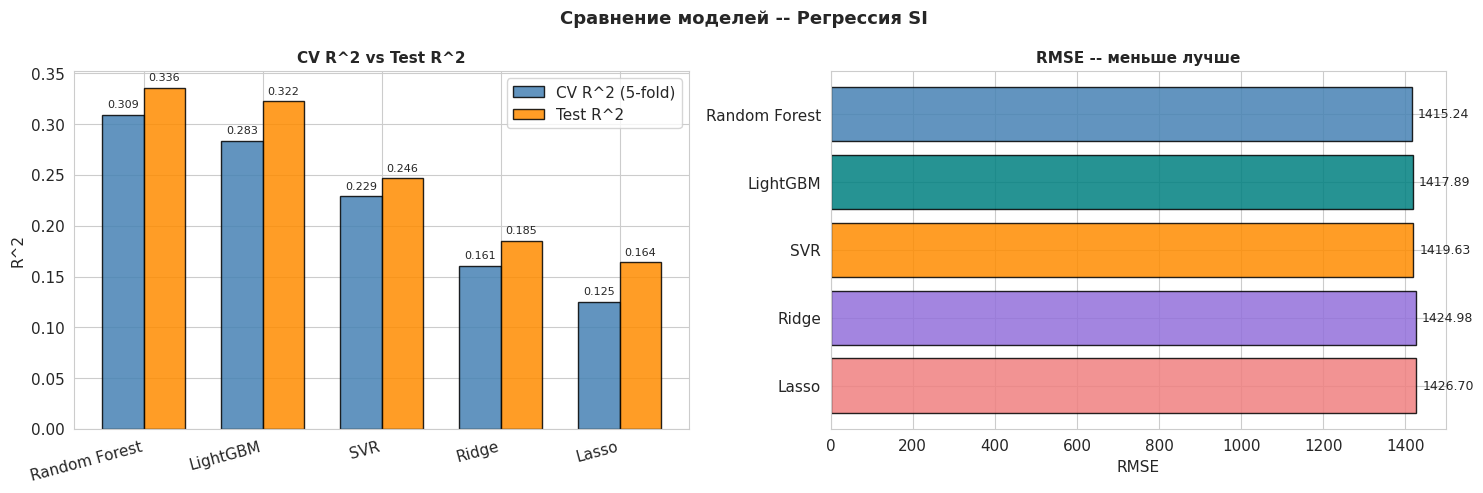

Лучшая модель: Random Forest  (Test R^2 = 0.3356)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models  = results_df['Модель'].tolist()
cv_r2s  = results_df['CV R^2 (5-fold)'].tolist()
tst_r2s = results_df['Test R^2'].tolist()
rmses   = results_df['RMSE'].tolist()
colors  = ['steelblue', 'teal', 'darkorange', 'mediumpurple', 'lightcoral']

# График 1 -- CV R^2 vs Test R^2
x = np.arange(len(models))
w = 0.35
b1 = axes[0].bar(x - w/2, cv_r2s,  w, label='CV R^2 (5-fold)',
                 color='steelblue', edgecolor='black', alpha=0.85)
b2 = axes[0].bar(x + w/2, tst_r2s, w, label='Test R^2',
                 color='darkorange', edgecolor='black', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylabel('R^2')
axes[0].set_title('CV R^2 vs Test R^2', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.7)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=8)

# График 2 -- RMSE (меньше = лучше)
clrs = [colors[models.index(m)] for m in models]
axes[1].barh(models[::-1], rmses[::-1], color=clrs[::-1], edgecolor='black', alpha=0.85)
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE -- меньше лучше', fontsize=11, fontweight='bold')
for i, v in enumerate(rmses[::-1]):
    axes[1].text(v + max(rmses)*0.01, i, f'{v:.2f}', va='center', fontsize=9)

plt.suptitle('Сравнение моделей -- Регрессия SI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reg_si_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

winner = results_df.iloc[0]['Модель']
print(f"Лучшая модель: {winner}  (Test R^2 = {results_df.iloc[0]['Test R^2']:.4f})")


#### Победитель определён -- смотрим ошибки и признаки

Большой разрыв CV R^2 - Test R^2 -> переобучение. Близкие значения -> хорошая генерализация.


## 8. Важность признаков и анализ остатков

### 8.1 Важность признаков (RF и LightGBM)


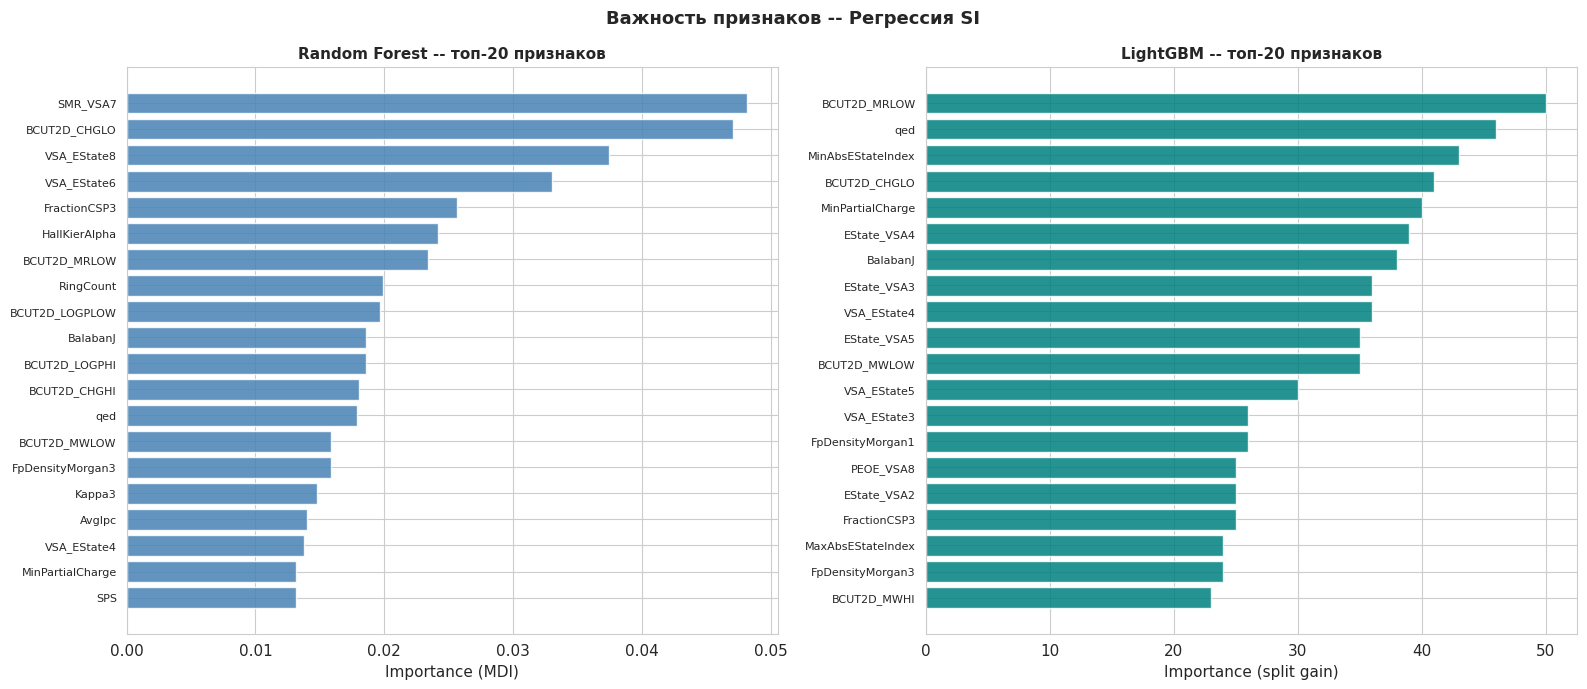

Общих признаков в топ-20 у RF и LightGBM: 9
  Признаки: BCUT2D_CHGLO, BCUT2D_MRLOW, BCUT2D_MWLOW, BalabanJ, FpDensityMorgan3, FractionCSP3, MinPartialCharge, VSA_EState4, qed


In [11]:
rf_imp  = pd.Series(best_rf.feature_importances_,  index=feature_cols).sort_values(ascending=False)
lgb_imp = pd.Series(best_lgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_rf = rf_imp.head(TOP_N)
axes[0].barh(range(TOP_N), top_rf.values[::-1], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(top_rf.index[::-1], fontsize=8)
axes[0].set_xlabel('Importance (MDI)')
axes[0].set_title(f'Random Forest -- топ-{TOP_N} признаков', fontsize=11, fontweight='bold')

top_lgb = lgb_imp.head(TOP_N)
axes[1].barh(range(TOP_N), top_lgb.values[::-1], color='teal', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels(top_lgb.index[::-1], fontsize=8)
axes[1].set_xlabel('Importance (split gain)')
axes[1].set_title(f'LightGBM -- топ-{TOP_N} признаков', fontsize=11, fontweight='bold')

plt.suptitle(f'Важность признаков -- Регрессия SI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reg_si_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

common = set(top_rf.index) & set(top_lgb.index)
print(f"Общих признаков в топ-{TOP_N} у RF и LightGBM: {len(common)}")
if common:
    print("  Признаки:", ', '.join(sorted(common)))


#### Признаки, входящие в топ-20 обеих моделей, -- наиболее надёжные предикторы

RF и LightGBM используют разные методы оценки важности (MDI vs. split gain), поэтому некоторое расхождение ожидаемо. Общие признаки -- наиболее значимые кандидаты для интерпретации.


### 8.2 Анализ остатков лучшей модели

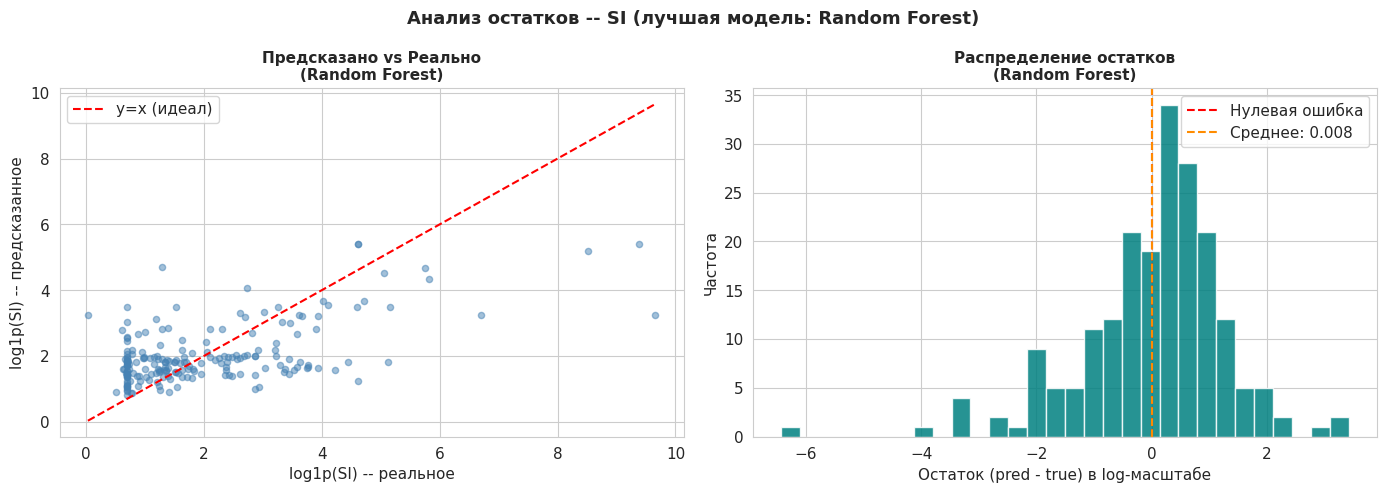

Среднее остатков: 0.0078  (~0 -- нет систематической ошибки)
Std остатков:     1.2680


In [12]:
# Используем лучшую модель по Test R^2
best_by_r2 = {
    'Ridge':         (best_ridge, X_test_sc, ridge_r2),
    'Lasso':         (best_lasso, X_test_sc, lasso_r2),
    'Random Forest': (best_rf,    X_test,    rf_r2),
    'LightGBM':      (best_lgb,   X_test,    lgb_r2),
    'SVR':           (best_svr,   X_test_sc, svr_r2),
}
winner_name = max(best_by_r2, key=lambda k: best_by_r2[k][2])
w_model, w_X, _ = best_by_r2[winner_name]

y_pred_w  = w_model.predict(w_X)
residuals = y_pred_w - y_test  # в log-пространстве

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Предсказано vs реально
axes[0].scatter(y_test, y_pred_w, alpha=0.5, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred_w.min()), max(y_test.max(), y_pred_w.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='y=x (идеал)')
axes[0].set_xlabel(f'log1p({TARGET}) -- реальное')
axes[0].set_ylabel(f'log1p({TARGET}) -- предсказанное')
axes[0].set_title(f'Предсказано vs Реально\n({winner_name})', fontsize=11, fontweight='bold')
axes[0].legend()

# Гистограмма остатков
axes[1].hist(residuals, bins=30, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Нулевая ошибка')
axes[1].axvline(residuals.mean(), color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Среднее: {residuals.mean():.3f}')
axes[1].set_xlabel('Остаток (pred - true) в log-масштабе')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение остатков\n({winner_name})', fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle(f'Анализ остатков -- SI (лучшая модель: {winner_name})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reg_si_residuals.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Среднее остатков: {residuals.mean():.4f}  (~0 -- нет систематической ошибки)")
print(f"Std остатков:     {residuals.std():.4f}")


#### Анализ остатков

- График "предсказано vs реально": точки должны лежать вдоль красной диагонали y=x
- Гистограмма остатков: симметрично центрирована около 0 -> нет систематического смещения (bias)
- Если остатки скошены -> модель систематически недо- или переоценивает значения в определённом диапазоне


## 9. Выводы и рекомендации

### Итоги регрессии SI

1. **Ridge / Lasso (baseline)** -- показывают линейный предел задачи. Если R^2 < 0.2 -- линейных зависимостей недостаточно. Lasso дополнительно выявляет минимальный информативный набор признаков через L1-обнуление.

2. **Random Forest** -- первый нелинейный шаг. Устойчив к выбросам, хорошо работает с mixed-type признаками. Ключевой вопрос: насколько он превосходит линейные модели?

3. **LightGBM** -- как правило, лучшая модель. Последовательная коррекция ошибок даёт точнее аппроксимацию при правильных `learning_rate` и `n_estimators`.

4. **SVR** -- хорош при малых выборках, но медленнее RF/LightGBM в подборе гиперпараметров.

**Особенность задачи SI:** SI = CC50/IC50 -- составная переменная. Альтернативная стратегия: предсказывать IC50 и CC50 независимо, затем вычислить SI = pred_CC50 / pred_IC50. Это может дать более точный результат, если обе регрессии работают хорошо.

